In [1]:
# 1. Load Data and Prepare Features
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
from src.features.feature_engineering import prepare_features
from src.models.train import train_models, evaluate_models, tune_hyperparameters

# Set MLflow tracking URI to project root database (SQLite for metadata, mlruns for artifacts)
import mlflow
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
mlflow.set_tracking_uri(f"sqlite:///{os.path.join(project_root, 'mlflow.db')}")
mlflow.set_experiment("Heart Disease Prediction")

df = pd.read_csv("../data/processed/processed_heart.csv")

X_train, X_test, y_train, y_test, preprocessor = prepare_features(df)

print(f"Dataset shape: {df.shape}")
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Dataset shape: (297, 14)
Training set size: 237
Test set size: 60


In [2]:
# 2. Train Initial Models with Cross-Validation
models, cv_results = train_models(X_train, y_train, preprocessor)

print("\nCross-Validation Results:")
for name, results in cv_results.items():
    print(f"{name}: {results['cv_mean']:.4f} (+/- {results['cv_std']:.4f})")

Logistic Regression trained successfully.
Logistic Regression - CV Accuracy: 0.8347 (+/- 0.0795)


Random Forest trained successfully.


Random Forest - CV Accuracy: 0.8137 (+/- 0.0903)

Cross-Validation Results:
Logistic Regression: 0.8347 (+/- 0.0795)
Random Forest: 0.8137 (+/- 0.0903)


In [3]:
# 3. Evaluate Initial Models
test_results = evaluate_models(models, X_test, y_test)


Logistic Regression - Test Set Evaluation:
Accuracy: 0.8167
Precision: 0.8696
Recall: 0.7143
ROC-AUC: 0.9408

Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.91      0.84        32
         1.0       0.87      0.71      0.78        28

    accuracy                           0.82        60
   macro avg       0.83      0.81      0.81        60
weighted avg       0.82      0.82      0.81        60


Random Forest - Test Set Evaluation:
Accuracy: 0.8500
Precision: 0.8519
Recall: 0.8214
ROC-AUC: 0.9358

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.88      0.86        32
         1.0       0.85      0.82      0.84        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



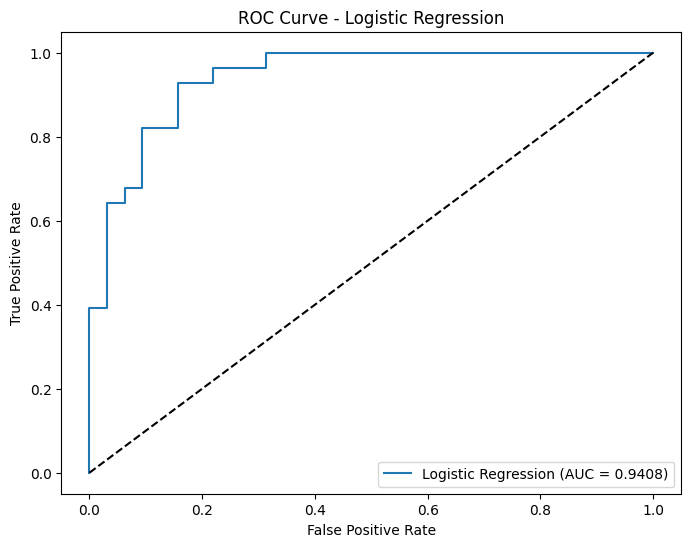

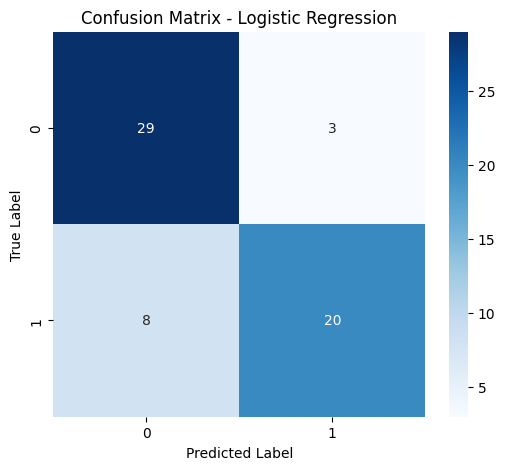

2026/07/09 21:01:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/07/09 21:01:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression (Initial) logged successfully.


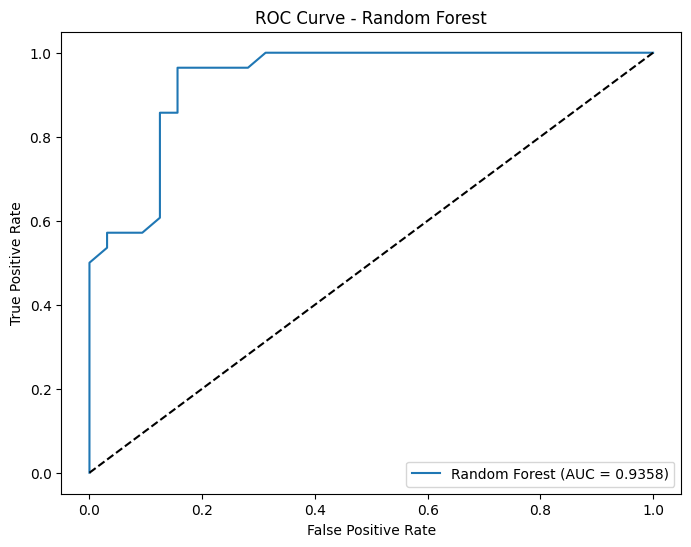

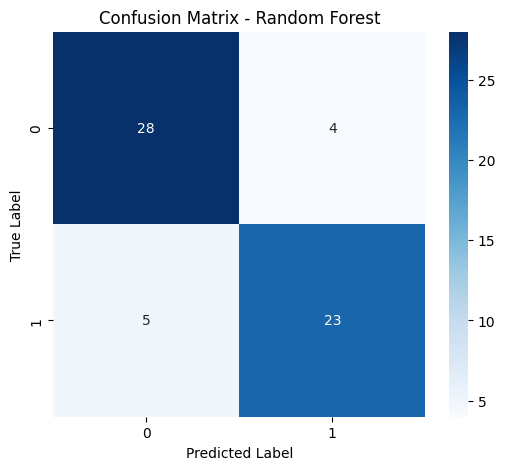

2026/07/09 21:01:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/07/09 21:01:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest (Initial) logged successfully.


In [4]:
# 4. Log Initial Models to MLflow
from src.mlflow.experiment_tracker import log_experiment
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, confusion_matrix
import seaborn as sns

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        "accuracy": test_results[name]['accuracy'],
        "precision": test_results[name]['precision'],
        "recall": test_results[name]['recall'],
        "roc_auc": test_results[name]['roc_auc'],
        "cv_accuracy": cv_results[name]['cv_mean'],
        "cv_std": cv_results[name]['cv_std']
    }
    
    params = {
        "model_type": name,
        "random_state": 42
    }
    
    # Generate ROC curve plot
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'{name} (AUC = {metrics["roc_auc"]:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.legend()
    plt.savefig(f'roc_curve_{name.replace(" ", "_")}.png')
    plt.show()
    
    # Generate confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'confusion_matrix_{name.replace(" ", "_")}.png')
    plt.show()
    
    artifacts = [
        f'roc_curve_{name.replace(" ", "_")}.png',
        f'confusion_matrix_{name.replace(" ", "_")}.png'
    ]
    
    log_experiment(
        model_name=f"{name} (Initial)",
        model=model,
        params=params,
        metrics=metrics,
        artifacts=artifacts
    )

In [5]:
# 5. Hyperparameter Tuning
tuned_models = tune_hyperparameters(X_train, y_train, preprocessor)


Tuning Logistic Regression...


C:\Program Files\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Logistic Regression params: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best ROC-AUC: 0.9056

Tuning Random Forest...


Best Random Forest params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
Best ROC-AUC: 0.9106


In [6]:
# 6. Evaluate Tuned Models
tuned_results = evaluate_models(tuned_models, X_test, y_test)


Logistic Regression (Tuned) - Test Set Evaluation:
Accuracy: 0.8500
Precision: 0.8800
Recall: 0.7857
ROC-AUC: 0.9397

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.91      0.87        32
         1.0       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60


Random Forest (Tuned) - Test Set Evaluation:
Accuracy: 0.8333
Precision: 0.8750
Recall: 0.7500
ROC-AUC: 0.9542

Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.91      0.85        32
         1.0       0.88      0.75      0.81        28

    accuracy                           0.83        60
   macro avg       0.84      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60



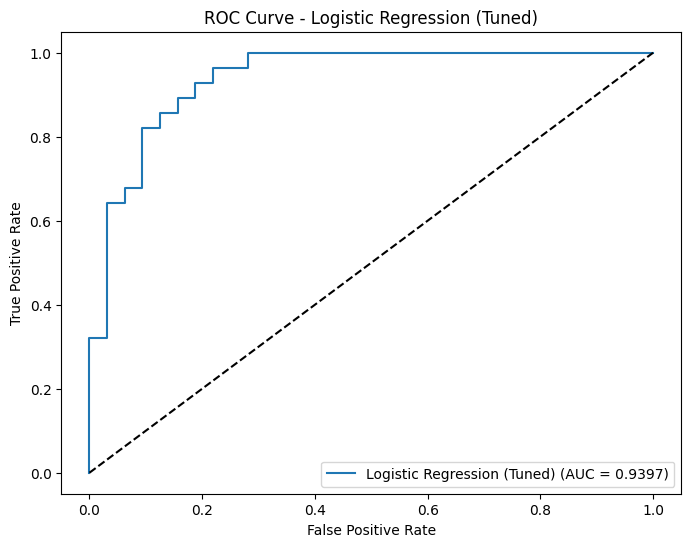

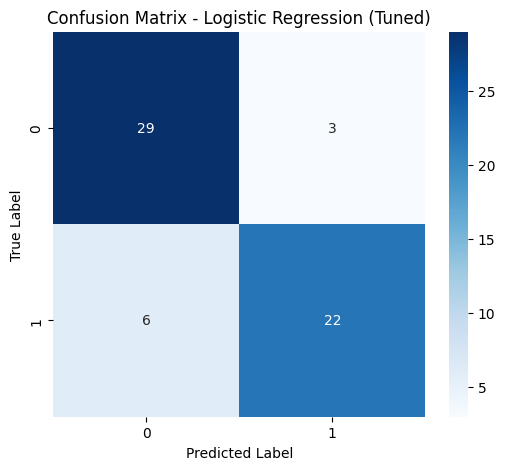

2026/07/09 21:01:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/07/09 21:01:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression (Tuned) logged successfully.


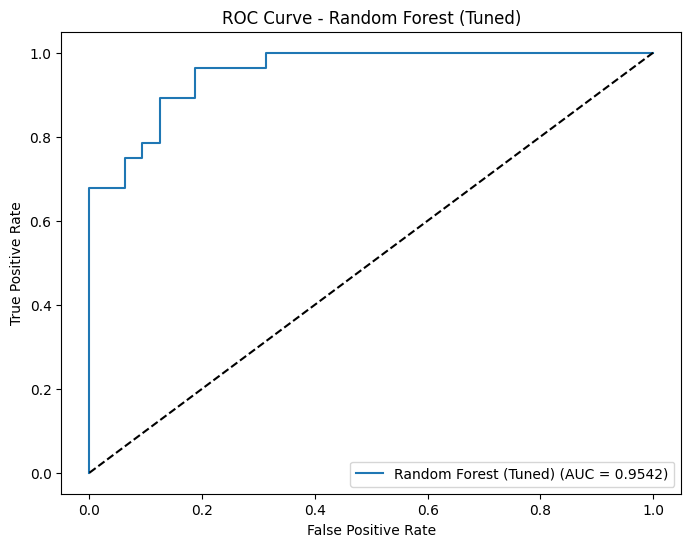

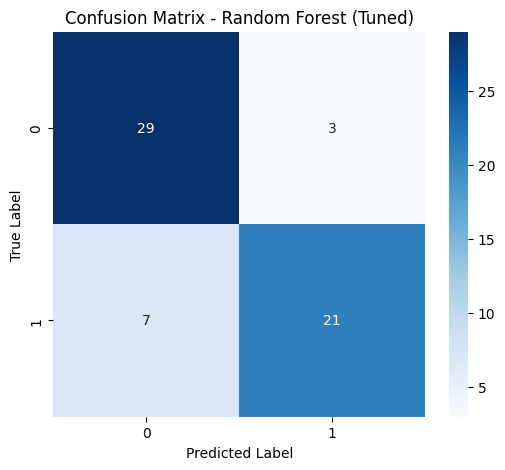

2026/07/09 21:02:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/07/09 21:02:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest (Tuned) logged successfully.


In [7]:
# 7. Log Tuned Models to MLflow
from sklearn.model_selection import GridSearchCV

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        "accuracy": tuned_results[name]['accuracy'],
        "precision": tuned_results[name]['precision'],
        "recall": tuned_results[name]['recall'],
        "roc_auc": tuned_results[name]['roc_auc']
    }
    
    # Extract parameters from the model
    if "Logistic Regression" in name:
        params = {
            "model_type": "Logistic Regression (Tuned)",
            "C": model.named_steps['classifier'].C,
            "penalty": model.named_steps['classifier'].penalty,
            "solver": model.named_steps['classifier'].solver,
            "random_state": 42
        }
    else:  # Random Forest
        params = {
            "model_type": "Random Forest (Tuned)",
            "n_estimators": model.named_steps['classifier'].n_estimators,
            "max_depth": model.named_steps['classifier'].max_depth,
            "min_samples_split": model.named_steps['classifier'].min_samples_split,
            "min_samples_leaf": model.named_steps['classifier'].min_samples_leaf,
            "random_state": 42
        }
    
    # Generate ROC curve plot
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'{name} (AUC = {metrics["roc_auc"]:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.legend()
    plt.savefig(f'roc_curve_{name.replace(" ", "_")}.png')
    plt.show()
    
    # Generate confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'confusion_matrix_{name.replace(" ", "_")}.png')
    plt.show()
    
    artifacts = [
        f'roc_curve_{name.replace(" ", "_")}.png',
        f'confusion_matrix_{name.replace(" ", "_")}.png'
    ]
    
    log_experiment(
        model_name=name,
        model=model,
        params=params,
        metrics=metrics,
        artifacts=artifacts
    )